In [1]:
# import of required packages
import time
import xarray as xr
import json
from tqdm.notebook import trange, tqdm
from earthkit.regrid import interpolate

#taken from Kamesh's example notebook
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cmocean

def worldmap(arr, idx, **kwargs):
    var = interpolate(arr[0,idx], {"grid": "O1280"}, {"grid": [1,1]})
    projection = ccrs.Robinson(central_longitude=-135.5808361)
    fig, ax = plt.subplots(
        figsize=(8, 4), subplot_kw={"projection": projection}, constrained_layout=True
    )
    ax.set_global()
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()
    ax.imshow(var, extent=xlims + ylims, origin="lower", **kwargs)
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)

import zarr 
from pathlib import Path
from pychunked_data_view.chunked_data_view import (
    AxisDefinition,
    ChunkedDataViewBuilder,
    ExtractorType,
)
from z3fdb.mapping import (
    FdbSource,
    FdbZarrArray,
    FdbZarrGroup,
    FdbZarrStore,
)
def open_view(fdb_config_path: Path):
    builder = ChunkedDataViewBuilder(fdb_config_path)
    builder.add_part(
        "class=od,"
        "domain=g,"
        "date=2025-07-05/2025-07-06/2025-07-07,"
        "expver=0001,"
        "levtype=sfc,"
        "param=167,"
        "step=0/1/2/3/4/5/6/7/8/9/10/11/12/13/14/15/16/17/18/19/20/21/22/23/24/25/26/27/28/29/30/31/32/33/34/35/36/37/38/39/40/41/42/43/44/45/46/47/48/49/50/51/52/53/54/55/56/57/58/59/60/61/62/63/64/65/66/67/68/69/70/71/72/73/74/75/76/77/78/79/80/81/82/83/84/85/86/87/88/89/90/93/96/99/102/105/108/111/114/117/120/123/126/129/132/135/138/141/144/150/156/162/168/174/180/186/192/198/204/210/216/222/228/234/240/246/252/258/264/270/276/282/288/294/300/306/312/318/324/330/336/342/348/354/360,"
        "stream=oper,"
        "time=0000/1200,"
        "type=fc",
        [AxisDefinition(["date", "time"], True), AxisDefinition(["step"], True)],
        ExtractorType.GRIB,
    )
    view = builder.build()
    mapping = FdbZarrStore(
        FdbZarrGroup(
            children=[
                FdbZarrArray(
                    name="data",
                    datasource=FdbSource(view),
                )
            ]
        )
    )
    return zarr.open_group(mapping, mode="r", zarr_format=3, use_consolidated=False)

import os
os.environ["FDB_HOME"] = "/home/fdbprod/"
fdb_prod_cfg=Path("/home/fdbprod/etc/fdb/config.yaml")

g = open_view(fdb_prod_cfg)

import itertools
from functools import reduce
import operator
def prod(iterable):
    return reduce(operator.mul, iterable, 1)

arr = g['data']
shape = arr.shape
iter = itertools.product(*[range(0, x) for x in shape[:-1]])
for x in tqdm(iter, total=prod(shape[:-1]), unit='field'):
    _ = arr[*x]

from matplotlib import animation

projection = ccrs.Robinson(central_longitude=-180)
fig = plt.figure()
ax = plt.axes(projection=projection)
ax.set_global()
xlims = ax.get_xlim()
ylims = ax.get_ylim()
#ax.add_feature(cf.COASTLINE, linewidth=0.8)
#ax.add_feature(cf.BORDERS, linewidth=0.4)
var = interpolate(arr[0,0], {"grid": "O1280"}, {"grid": [1,1]})
img = ax.imshow(var, extent=xlims + ylims, origin="upper", animated=True)

def update(idx):
    var = interpolate(arr[0,idx], {"grid": "O1280"}, {"grid": [1,1]})
    img.set_array(var)
    return ax,
    
anim = animation.FuncAnimation(fig, update, frames=range(0,100), interval=30, blit=True)

In [2]:
import zarr 
from pathlib import Path
from pychunked_data_view.chunked_data_view import (
    AxisDefinition,
    ChunkedDataViewBuilder,
    ExtractorType,
)
from z3fdb.mapping import (
    FdbSource,
    FdbZarrArray,
    FdbZarrGroup,
    FdbZarrStore,
)
def open_view(fdb_config_path: Path):
    builder = ChunkedDataViewBuilder(fdb_config_path)
    builder.add_part(
        "class=od,"
        "domain=g,"
        "date=2025-07-05/2025-07-06/2025-07-07,"
        "expver=0001,"
        "levtype=sfc,"
        "param=167,"
        "step=0/1/2/3/4/5/6/7/8/9/10/11/12/13/14/15/16/17/18/19/20/21/22/23/24/25/26/27/28/29/30/31/32/33/34/35/36/37/38/39/40/41/42/43/44/45/46/47/48/49/50/51/52/53/54/55/56/57/58/59/60/61/62/63/64/65/66/67/68/69/70/71/72/73/74/75/76/77/78/79/80/81/82/83/84/85/86/87/88/89/90/93/96/99/102/105/108/111/114/117/120/123/126/129/132/135/138/141/144/150/156/162/168/174/180/186/192/198/204/210/216/222/228/234/240/246/252/258/264/270/276/282/288/294/300/306/312/318/324/330/336/342/348/354/360,"
        "stream=oper,"
        "time=0000/1200,"
        "type=fc",
        [AxisDefinition(["date", "time"], True), AxisDefinition(["step"], True)],
        ExtractorType.GRIB,
    )
    view = builder.build()
    mapping = FdbZarrStore(
        FdbZarrGroup(
            children=[
                FdbZarrArray(
                    name="data",
                    datasource=FdbSource(view),
                )
            ]
        )
    )
    return zarr.open_group(mapping, mode="r", zarr_format=3, use_consolidated=False)

In [3]:
import os
os.environ["FDB_HOME"] = "/home/fdbprod/"
fdb_prod_cfg=Path("/home/fdbprod/etc/fdb/config.yaml")

g = open_view(fdb_prod_cfg)

In [4]:
import itertools
from functools import reduce
import operator
def prod(iterable):
    return reduce(operator.mul, iterable, 1)

arr = g['data']
shape = arr.shape
iter = itertools.product(*[range(0, x) for x in shape[:-1]])
for x in tqdm(iter, total=prod(shape[:-1]), unit='field'):
    _ = arr[*x]

  0%|          | 0/870 [00:00<?, ?field/s]

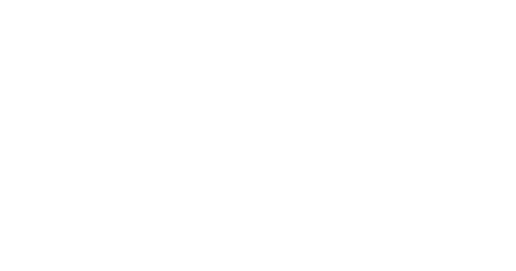

In [6]:
from matplotlib import animation

projection = ccrs.Robinson(central_longitude=-180)
fig = plt.figure()
ax = plt.axes(projection=projection)
ax.set_global()
xlims = ax.get_xlim()
ylims = ax.get_ylim()
#ax.add_feature(cf.COASTLINE, linewidth=0.8)
#ax.add_feature(cf.BORDERS, linewidth=0.4)
var = interpolate(arr[0,0], {"grid": "O1280"}, {"grid": [1,1]})
img = ax.imshow(var, extent=xlims + ylims, origin="upper", animated=True)

def update(idx):
    var = interpolate(arr[0,idx], {"grid": "O1280"}, {"grid": [1,1]})
    img.set_array(var)
    return ax,
    
anim = animation.FuncAnimation(fig, update, frames=range(0,100), interval=30, blit=True)